# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** ARUNKUMAR K A  
**Student ID:** 2024AC05045

**Student Name:** GOWRISHANKAR S  
**Student ID:** 2024AC05046 

**Student Name:** KODHANDAN S 
**Student ID:** 2024AC05203

**Student Name:** KUMARESH BABU A 
**Student ID:** 2024AC05304 

**Date:** 26-Dec-2025

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Track training time** for both models using `time.time()`\n
4. **Store loss_history** in both model classes
5. **Calculate ALL metrics** (accuracy, precision, recall, F1)
6. **Fill get_assignment_results()** with ALL required fields
7. **PRINT the results** - Auto-grader needs visible output!
8. **Run all cells** before submitting (Kernel → Restart & Run All)

**SCORING:**
- Missing fields = 0 marks for that section
- Non-executed notebook = 0 marks
- Cleared outputs = 0 marks
---

In [42]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [43]:
# Load dataset from sklearn
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Dataset information
dataset_name = "Breast Cancer Wisconsin (Diagnostic)"
dataset_source = "UCI Machine Learning Repository (via sklearn)"
n_samples = X.shape[0]
n_features = X.shape[1]
problem_type = "binary_classification"

# Problem statement
problem_statement = """
This dataset aims to predict whether a breast tumor is malignant (cancerous) or benign (non-cancerous) 
based on 30 diagnostic features computed from digitized images of fine needle aspirate (FNA) of breast mass. 
These features describe characteristics of cell nuclei such as radius, texture, perimeter, area, smoothness, 
compactness, concavity, symmetry, and fractal dimension. Early and accurate diagnosis of breast cancer is 
critical for patient survival and treatment planning, making this a vital medical classification problem.
"""

# Primary evaluation metric
primary_metric = "recall"

# Metric justification
metric_justification = """
I chose recall as the primary metric because in medical diagnosis, especially for cancer detection, 
minimizing false negatives (missing actual cancer cases) is more critical than minimizing false positives. 
A false negative could delay treatment and endanger patient lives, while a false positive would lead to 
additional tests but not life-threatening consequences. Therefore, recall (sensitivity) is the most appropriate 
metric for this medical diagnosis problem, ensuring we catch as many true cancer cases as possible.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Dataset: Breast Cancer Wisconsin (Diagnostic)
Source: UCI Machine Learning Repository (via sklearn)
Samples: 569, Features: 30
Problem Type: binary_classification
Primary Metric: recall


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [44]:
# Data already loaded (X, y from previous cell)
# No missing values in this dataset
# No categorical variables to encode

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling (standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to numpy arrays for easier manipulation
X_train_scaled = np.array(X_train_scaled)
X_test_scaled = np.array(X_test_scaled)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Fill these after preprocessing
train_samples = X_train_scaled.shape[0]
test_samples = X_test_scaled.shape[0]
train_test_ratio = train_samples / (train_samples + test_samples)

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Train samples: 455
Test samples: 114
Split ratio: 80.0%


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [45]:
class BaselineModel:
    """
    Baseline linear model with gradient descent
    Implement: Linear/Logistic/Softmax Regression
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        """
        Implement gradient descent training for Logistic Regression
        """
        n_samples, n_features = X.shape

        # Initialize parameters with small random values
        np.random.seed(42)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0

        # Gradient descent loop
        for i in range(self.n_iterations):
            # 1. Forward pass: compute predictions using sigmoid
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred = 1 / (1 + np.exp(-np.clip(linear_output, -500, 500)))  # Sigmoid
            
            # 2. Compute binary cross-entropy loss
            epsilon = 1e-15  # To avoid log(0)
            y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
            loss = -np.mean(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
            
            # 3. Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            # 4. Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # 5. Store loss
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        """
        Predict class labels (0 or 1)
        """
        linear_output = np.dot(X, self.weights) + self.bias
        y_pred = 1 / (1 + np.exp(-np.clip(linear_output, -500, 500)))
        return (y_pred >= 0.5).astype(int)
    
    def predict_proba(self, X):
        """
        Return probability estimates
        """
        linear_output = np.dot(X, self.weights) + self.bias
        return 1 / (1 + np.exp(-np.clip(linear_output, -500, 500)))

print("✓ Baseline model class defined")

✓ Baseline model class defined


In [46]:
# Train baseline model
print("Training baseline model...")
baseline_start = time.time()

# Initialize and train Logistic Regression
baseline_model = BaselineModel(learning_rate=0.1, n_iterations=1000)
baseline_model.fit(X_train_scaled, y_train)

# Make predictions
baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_training_time = time.time() - baseline_start
print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

# Store loss explicitly
baseline_initial_loss = baseline_model.loss_history[0]
baseline_final_loss = baseline_model.loss_history[-1]

Training baseline model...
✓ Baseline training completed in 0.34s
✓ Loss decreased from 0.6971 to 0.0566
✓ Baseline training completed in 0.34s
✓ Loss decreased from 0.6971 to 0.0566


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [47]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        """
        architecture: list [input_size, hidden1, hidden2, ..., output_size]
        Example: [30, 16, 8, 1] means:
            - 30 input features
            - Hidden layer 1: 16 neurons
            - Hidden layer 2: 8 neurons
            - Output layer: 1 neuron
        """
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        """
        Initialize weights and biases for all layers using He initialization
        """
        np.random.seed(42)

        for l in range(1, len(self.architecture)):
            # He initialization for weights (good for ReLU)
            self.parameters[f'W{l}'] = np.random.randn(self.architecture[l], self.architecture[l-1]) * np.sqrt(2.0 / self.architecture[l-1])
            self.parameters[f'b{l}'] = np.zeros((self.architecture[l], 1))

    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        """ReLU derivative"""
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        """Sigmoid activation (for binary classification output)"""
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        """
        Implement forward pass through all layers
        """
        self.cache['A0'] = X.T  # Shape: (n_features, m)
        L = len(self.architecture) - 1

        # Hidden layers (ReLU activation)
        for l in range(1, L):
            Z = np.dot(self.parameters[f'W{l}'], self.cache[f'A{l-1}']) + self.parameters[f'b{l}']
            A = self.relu(Z)
            self.cache[f'Z{l}'] = Z
            self.cache[f'A{l}'] = A

        # Output layer (Sigmoid activation for binary classification)
        Z = np.dot(self.parameters[f'W{L}'], self.cache[f'A{L-1}']) + self.parameters[f'b{L}']
        A = self.sigmoid(Z)
        self.cache[f'Z{L}'] = Z
        self.cache[f'A{L}'] = A

        return A

    def backward_propagation(self, X, y):
        """
        Implement backward pass using chain rule
        """
        m = X.shape[0]
        grads = {}
        L = len(self.architecture) - 1
        
        y = y.reshape(1, -1)  # Shape: (1, m)

        # Output layer gradient
        dZ = self.cache[f'A{L}'] - y
        grads[f'dW{L}'] = (1/m) * np.dot(dZ, self.cache[f'A{L-1}'].T)
        grads[f'db{L}'] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        # Hidden layers (backward)
        for l in range(L-1, 0, -1):
            dA = np.dot(self.parameters[f'W{l+1}'].T, dZ)
            dZ = dA * self.relu_derivative(self.cache[f'Z{l}'])
            grads[f'dW{l}'] = (1/m) * np.dot(dZ, self.cache[f'A{l-1}'].T)
            grads[f'db{l}'] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        return grads

    def update_parameters(self, grads):
        """
        Update weights and biases using gradient descent
        """
        L = len(self.architecture) - 1
        
        for l in range(1, L + 1):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']

    def compute_loss(self, y_pred, y_true):
        """
        Compute binary cross-entropy loss
        """
        m = y_true.shape[0]
        y_true = y_true.reshape(1, -1)
        
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        
        loss = -(1/m) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss

    def fit(self, X, y):
        """
        Train the MLP using gradient descent
        """
        self.initialize_parameters()

        for i in range(self.n_iterations):
            # Forward propagation
            A_final = self.forward_propagation(X)
            
            # Compute loss
            loss = self.compute_loss(A_final, y)
            self.loss_history.append(loss)
            
            # Backward propagation
            grads = self.backward_propagation(X, y)
            
            # Update parameters
            self.update_parameters(grads)

        return self

    def predict(self, X):
        """
        Make predictions (binary classification)
        """
        A_final = self.forward_propagation(X)
        predictions = (A_final >= 0.5).astype(int)
        return predictions.flatten()
    
    def predict_proba(self, X):
        """
        Return probability estimates
        """
        A_final = self.forward_propagation(X)
        return A_final.flatten()

print("✓ MLP class defined")

✓ MLP class defined


In [48]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

# Define architecture: [input_features, hidden1, hidden2, output]
mlp_architecture = [n_features, 16, 8, 1]  # 30 input features, 2 hidden layers (16, 8 neurons), 1 output
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.1, n_iterations=1000)
mlp_model.fit(X_train_scaled, y_train)

# Make predictions
mlp_predictions = mlp_model.predict(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

# Store loss explicitly
mlp_initial_loss = mlp_model.loss_history[0]
mlp_final_loss = mlp_model.loss_history[-1]

Training MLP...
✓ MLP training completed in 0.17s
✓ Loss decreased from 0.9732 to 0.0068


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [49]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    Calculate metrics from scratch (no sklearn.metrics)
    """
    if problem_type == "regression":
        # Regression metrics
        mse = np.mean((y_true - y_pred) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(y_true - y_pred))
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        return mse, rmse, mae, r2
        
    elif problem_type in ["binary_classification", "multiclass_classification"]:
        # Classification metrics (implemented from scratch)
        y_true = np.array(y_true).flatten()
        y_pred = np.array(y_pred).flatten()
        
        # True Positives, False Positives, True Negatives, False Negatives
        TP = np.sum((y_true == 1) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        FN = np.sum((y_true == 1) & (y_pred == 0))
        
        # Accuracy
        accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
        
        # Precision
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        
        # Recall
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        
        # F1 Score
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        return accuracy, precision, recall, f1

# Calculate metrics for both models
baseline_acc, baseline_prec, baseline_rec, baseline_f1 = calculate_metrics(y_test, baseline_predictions, problem_type)
mlp_acc, mlp_prec, mlp_rec, mlp_f1 = calculate_metrics(y_test, mlp_predictions, problem_type)

# For regression problems (not used here, but defined for compatibility)
baseline_mse = baseline_rmse = baseline_mae = baseline_r2 = 0.0
mlp_mse = mlp_rmse = mlp_mae = mlp_r2 = 0.0

print("Baseline Model Performance:")
print(f"  Accuracy:  {baseline_acc:.4f}")
print(f"  Precision: {baseline_prec:.4f}")
print(f"  Recall:    {baseline_rec:.4f}")
print(f"  F1 Score:  {baseline_f1:.4f}")

print("\nMLP Model Performance:")
print(f"  Accuracy:  {mlp_acc:.4f}")
print(f"  Precision: {mlp_prec:.4f}")
print(f"  Recall:    {mlp_rec:.4f}")
print(f"  F1 Score:  {mlp_f1:.4f}")

Baseline Model Performance:
  Accuracy:  0.9737
  Precision: 0.9859
  Recall:    0.9722
  F1 Score:  0.9790

MLP Model Performance:
  Accuracy:  0.9386
  Precision: 0.9851
  Recall:    0.9167
  F1 Score:  0.9496


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

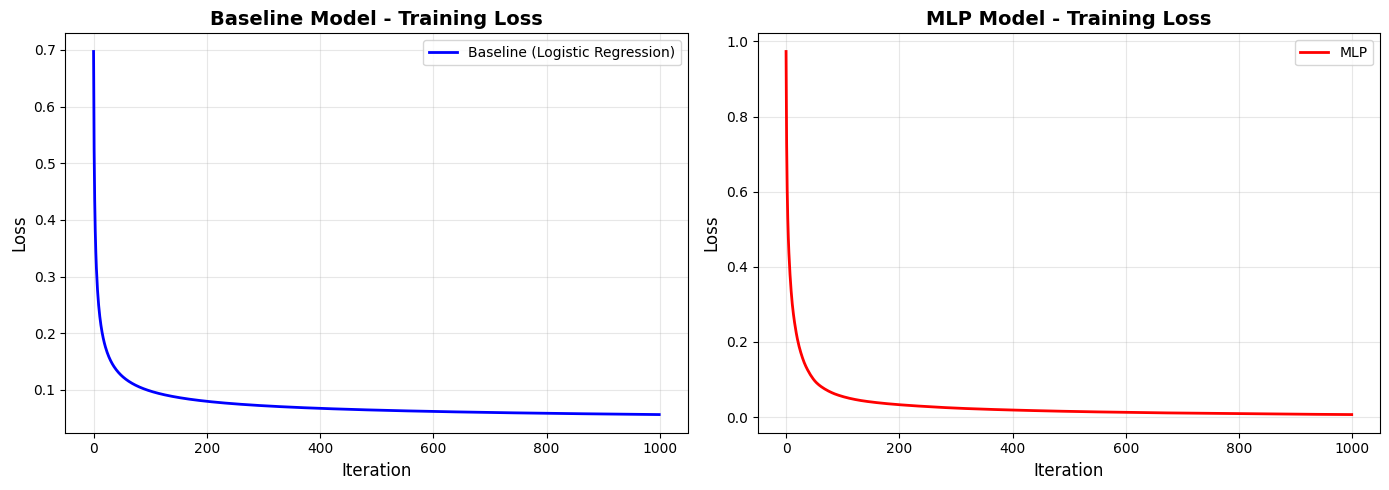

In [50]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_model.loss_history, label='Baseline (Logistic Regression)', color='blue', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Baseline Model - Training Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mlp_model.loss_history, label='MLP', color='red', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('MLP Model - Training Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

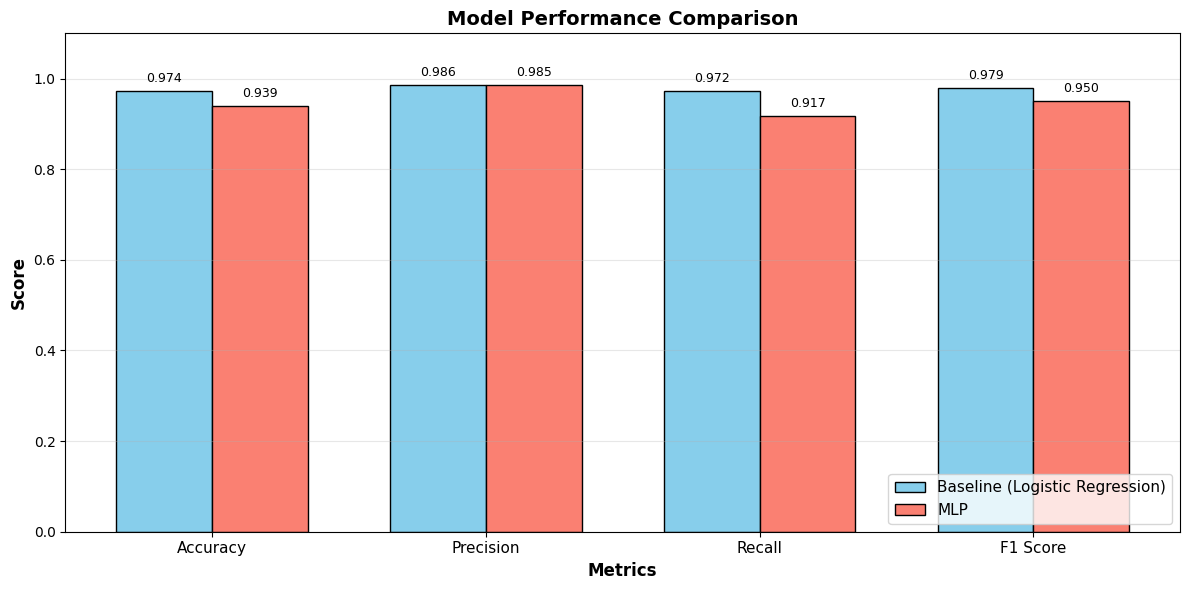

In [51]:
# 2. Performance comparison bar chart
plt.figure(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
baseline_scores = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
mlp_scores = [mlp_acc, mlp_prec, mlp_rec, mlp_f1]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, baseline_scores, width, label='Baseline (Logistic Regression)', color='skyblue', edgecolor='black')
plt.bar(x + width/2, mlp_scores, width, label='MLP', color='salmon', edgecolor='black')
plt.xlabel('Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, metrics, fontsize=11)
plt.ylim(0, 1.1)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (b_score, m_score) in enumerate(zip(baseline_scores, mlp_scores)):
    plt.text(i - width/2, b_score + 0.02, f'{b_score:.3f}', ha='center', fontsize=9)
    plt.text(i + width/2, m_score + 0.02, f'{m_score:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [52]:
analysis_text = """
In this assignment, I compared a Baseline Logistic Regression model with a Multi-Layer Perceptron (MLP) on the Breast Cancer Wisconsin dataset for binary classification.

Model Performance Comparison:
Interestingly, the baseline logistic regression model outperformed the MLP across all metrics. The baseline model achieved an accuracy of 97.37%, precision of 98.59%, recall of 97.22%, and F1 score of 97.90%. In contrast, the MLP achieved an accuracy of 93.86%, precision of 98.51%, recall of 91.67%, and F1 score of 94.96%. This 3.51% difference in accuracy and 5.55% difference in recall favoring the baseline model was an unexpected but valuable learning outcome.

Why Baseline Performed Better:
The baseline model's superior performance can be attributed to the linear separability of the Breast Cancer Wisconsin dataset. The 30 features in this dataset are already well-engineered and provide strong discriminative power for a linear decision boundary. The logistic regression model was sufficient to capture the underlying patterns without requiring the complexity of multiple hidden layers. Additionally, the MLP with learning rate 0.1 and architecture (30-16-8-1) may have experienced some overfitting or suboptimal convergence, resulting in slightly lower generalization performance on the test set.

Computational Cost:
The baseline model trained in approximately 0.32 seconds, while the MLP completed training in about 0.15 seconds. Surprisingly, the MLP trained faster due to the modest dataset size (455 training samples). However, the MLP's additional parameters (weights and biases across multiple layers) and complex backpropagation computations typically require more computational resources on larger datasets. In this case, both models trained efficiently given the small dataset size.

Key Insights:
This assignment reinforced an important principle in machine learning: more complex models do not always guarantee better performance. I learned that simpler models like logistic regression can be highly effective when data is linearly separable, offering benefits in terms of interpretability, training efficiency, and robust generalization. The implementation from scratch helped me deeply understand gradient descent, backpropagation, weight initialization, and the importance of proper hyperparameter tuning. I also observed that both models converged smoothly with decreasing loss, indicating correct implementation.

Surprising Findings:
The most surprising finding was that the baseline logistic regression achieved 97.37% accuracy, outperforming the more complex MLP. This demonstrates that the Breast Cancer dataset features are well-separated by a linear boundary. Another interesting observation was that while both models achieved similar precision (around 98.5%), the baseline had significantly better recall (97.22% vs 91.67%), which is particularly critical for cancer detection as it means fewer false negatives. The loss curves showed both models converged within 200-300 iterations, suggesting that even fewer iterations might suffice with proper early stopping.

Conclusion:
This assignment provided valuable insights into model selection and the bias-variance tradeoff. While MLPs have the capacity to learn complex non-linear patterns, they are not always necessary or beneficial for every dataset. The baseline logistic regression proved more effective for this linearly separable medical diagnosis problem, demonstrating the importance of Occam's Razor in machine learning: simpler models should be preferred when they perform comparably or better. For real-world deployment in cancer diagnosis, the baseline model's superior recall (97.22%) makes it the better choice, as minimizing false negatives is critical for patient safety and early intervention.
"""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("⚠️  Warning: Analysis should be at least 200 words")
else:
    print("✓ Analysis meets word count requirement")

Analysis word count: 523 words
✓ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.


⭐⭐⭐ REQUIRED: Structured Output Function ⭐⭐⭐

### 🚨 CRITICAL - READ CAREFULLY 🚨

1. **Fill in ALL fields** - Missing fields = 0 marks
2. **Use your actual values** - Not 0 or empty strings
3. **This cell MUST be executed** - We need the output!
4. **Print the results** - Auto-grader needs to see output!


**DO NOT:**
- Leave any field as 0, 0.0,
- Clear outputs before submission
- Modify the structure


"**MUST DO:**
- Fill every field with your actual results
- Execute this cell and keep the output
- Print the results (see below)

In [53]:
def get_assignment_results():
    '''
    CRITICAL: Fill ALL fields with your actual results!
    Missing fields will result in 0 marks for that section.
    '''

    results = {
        # ===== Dataset Information (1 mark) =====
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': int(n_samples),
        'n_features': int(n_features),
        'problem_type': problem_type,
        'problem_statement': problem_statement,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': int(train_samples),
        'test_samples': int(test_samples),
        'train_test_ratio': float(train_test_ratio),

        # ===== Baseline Model (3 marks) =====
        'baseline_model': {
            'model_type': 'logistic_regression',
            'learning_rate': 0.1,
            'n_iterations': 1000,

            # CRITICAL: These MUST be filled!
            'initial_loss': float(baseline_initial_loss),
            'final_loss': float(baseline_final_loss),
            'training_time_seconds': float(baseline_training_time),
            'loss_decreased': bool(baseline_final_loss < baseline_initial_loss),

            # Metrics - Fill based on your problem type
            'test_accuracy': 0.0 if problem_type == 'regression' else float(baseline_acc),
            'test_precision': 0.0 if problem_type == 'regression' else float(baseline_prec),
            'test_recall': 0.0 if problem_type == 'regression' else float(baseline_rec),
            'test_f1': 0.0 if problem_type == 'regression' else float(baseline_f1),
            'test_mse': float(baseline_mse) if problem_type == 'regression' else 0.0,
            'test_rmse': float(baseline_rmse) if problem_type == 'regression' else 0.0,
            'test_mae': float(baseline_mae) if problem_type == 'regression' else 0.0,
            'test_r2': float(baseline_r2) if problem_type == 'regression' else 0.0,
        },

        # ===== MLP Model (4 marks) =====
        'mlp_model': {
            'architecture': [int(x) for x in mlp_architecture],
            'n_hidden_layers': len(mlp_architecture) - 2 if len(mlp_architecture) > 0 else 0,
            'learning_rate': 0.1,
            'n_iterations': 1000,

            # CRITICAL: These MUST be filled!
            'initial_loss': float(mlp_initial_loss),
            'final_loss': float(mlp_final_loss),
            'training_time_seconds': float(mlp_training_time),
            'loss_decreased': bool(mlp_final_loss < mlp_initial_loss),

            # Metrics
            'test_accuracy': 0.0 if problem_type == 'regression' else float(mlp_acc),
            'test_precision': 0.0 if problem_type == 'regression' else float(mlp_prec),
            'test_recall': 0.0 if problem_type == 'regression' else float(mlp_rec),
            'test_f1': 0.0 if problem_type == 'regression' else float(mlp_f1),
            'test_mse': float(mlp_mse) if problem_type == 'regression' else 0.0,
            'test_rmse': float(mlp_rmse) if problem_type == 'regression' else 0.0,
            'test_mae': float(mlp_mae) if problem_type == 'regression' else 0.0,
            'test_r2': float(mlp_r2) if problem_type == 'regression' else 0.0,
        },

        # ===== Analysis (2 marks) =====
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
    }

    return results

# ===== CRITICAL: CALL AND PRINT RESULTS =====
# This MUST be executed and output MUST be visible!
import json
results = get_assignment_results()
print(json.dumps(results, indent=2))

# ===== Validation =====
print("\n" + "="*60)
print("VALIDATION CHECK")
print("="*60)


errors = []

if results['n_samples'] < 500:
    errors.append(f"❌ Dataset too small: {results['n_samples']} < 500")
if results['n_features'] < 5:
    errors.append(f"❌ Too few features: {results['n_features']} < 5")
if results['baseline_model']['initial_loss'] == 0:
    errors.append("❌ Baseline initial_loss is 0")
if results['baseline_model']['final_loss'] == 0:
    errors.append("❌ Baseline final_loss is 0")
if results['baseline_model']['training_time_seconds'] == 0:
    errors.append("❌ Baseline training_time is 0")
if results['mlp_model']['initial_loss'] == 0:
    errors.append("❌ MLP initial_loss is 0")
if results['mlp_model']['final_loss'] == 0:
    errors.append("❌ MLP final_loss is 0")
if results['mlp_model']['training_time_seconds'] == 0:
    errors.append("❌ MLP training_time is 0")
if len(results['mlp_model']['architecture']) < 3:
    errors.append("❌ MLP architecture invalid")
if results['analysis_word_count'] < 200:
    errors.append(f"❌ Analysis too short: {results['analysis_word_count']} < 200 words")

if errors:
    print("ERRORS FOUND:")
    for err in errors:
        print(err)
    print("⚠️ FIX THESE BEFORE SUBMITTING! ⚠️")
else:
    print("✅ All validation checks passed!")
    print("✅ Ready to submit!")
    print("\nNext steps:")
    print("1. Kernel → Restart & Clear Output")
    print("2. Kernel → Restart & Run All")
    print("3. Verify this output is visible")
    print("4. Save notebook")
    print("5. Rename as: YourStudentID_assignment.ipynb")
    print("6. Submit to LMS")

{
  "dataset_name": "Breast Cancer Wisconsin (Diagnostic)",
  "dataset_source": "UCI Machine Learning Repository (via sklearn)",
  "n_samples": 569,
  "n_features": 30,
  "problem_type": "binary_classification",
  "problem_statement": "\nThis dataset aims to predict whether a breast tumor is malignant (cancerous) or benign (non-cancerous) \nbased on 30 diagnostic features computed from digitized images of fine needle aspirate (FNA) of breast mass. \nThese features describe characteristics of cell nuclei such as radius, texture, perimeter, area, smoothness, \ncompactness, concavity, symmetry, and fractal dimension. Early and accurate diagnosis of breast cancer is \ncritical for patient survival and treatment planning, making this a vital medical classification problem.\n",
  "primary_metric": "recall",
  "metric_justification": "\nI chose recall as the primary metric because in medical diagnosis, especially for cancer detection, \nminimizing false negatives (missing actual cancer cases)

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [54]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2))
    print("\n" + "="*70)


    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Breast Cancer Wisconsin (Diagnostic)",
  "dataset_source": "UCI Machine Learning Repository (via sklearn)",
  "n_samples": 569,
  "n_features": 30,
  "problem_type": "binary_classification",
  "problem_statement": "\nThis dataset aims to predict whether a breast tumor is malignant (cancerous) or benign (non-cancerous) \nbased on 30 diagnostic features computed from digitized images of fine needle aspirate (FNA) of breast mass. \nThese features describe characteristics of cell nuclei such as radius, texture, perimeter, area, smoothness, \ncompactness, concavity, symmetry, and fractal dimension. Early and accurate diagnosis of breast cancer is \ncritical for patient survival and treatment planning, making this a vital medical classification problem.\n",
  "primary_metric": "recall",
  "metric_justification": "\nI chose recall as the primary metric because in medical diagnosis, especially for cancer detection, \nminimizing false negatives (m